# Activation energy

In [176]:
from dbm import sqlite3

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

thermal_data = pd.read_csv("thermal_data_2.csv", sep=",", decimal='.')

reduce_thermal_data = thermal_data.iloc[:, :]

array_thermal_data = reduce_thermal_data.to_numpy()

reduce_thermal_data

,temp,rate
0,21,90.3
1,25,145.0
2,28,199.0
3,32,255.0
4,34,281.0
5,37,301.0
6,40,327.0
7,45,289.0
8,50,238.0


In [177]:
kelvin = 273.15
temp = array_thermal_data[:, 0] #+ kelvin
velocity = array_thermal_data[:, 1]

print(f"Temp in Kelvin: {temp}")
print(f"Reaction rate: {velocity}")

Temp in Kelvin: [21. 25. 28. 32. 34. 37. 40. 45. 50.]
Reaction rate: [ 90.3 145.  199.  255.  281.  301.  327.  289.  238. ]


We get ln(velocity) and the inverse of the temperture. By plotting these points we can easily find and show the maximum velocity.


In [227]:
ln_velocity = np.log(velocity)
inverse_temp = 1/temp

ln_velocity_slope, ln_velocity_inter = np.polyfit(inverse_temp,ln_velocity, 1)

print(f"inverse Kelvin value: {inverse_temp}")

inverse Kelvin value: [0.04761905 0.04       0.03571429 0.03125    0.02941176 0.02702703
 0.025      0.02222222 0.02      ]


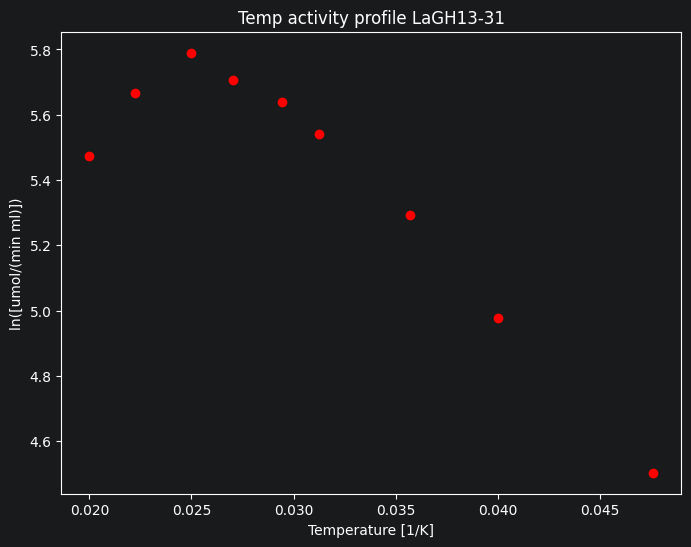

In [179]:
plt.figure(figsize=(8, 6))
plt.scatter(inverse_temp, ln_velocity, color = 'red')
plt.title("Temp activity profile LaGH13-31")
plt.xlabel("Temperature [1/K]")
plt.ylabel("ln([umol/(min ml)])")
plt.grid(False)
plt.show()

Now that we know the maximum velocity and begin to slice the graph until that point, and make the best line of fit. We then obtain the gradient of this line to calculate the activation energy.

In [180]:
line_inv_temp = inverse_temp[:4]
line_ln_velocity = ln_velocity[:4]

slope_vel, inter_vel = np.polyfit(line_inv_temp, line_ln_velocity, 1)

print(f"slope: ", slope_vel)
print(f"intercept: ", inter_vel)

slope:  -64.21719954801733
intercept:  7.5603370840476956


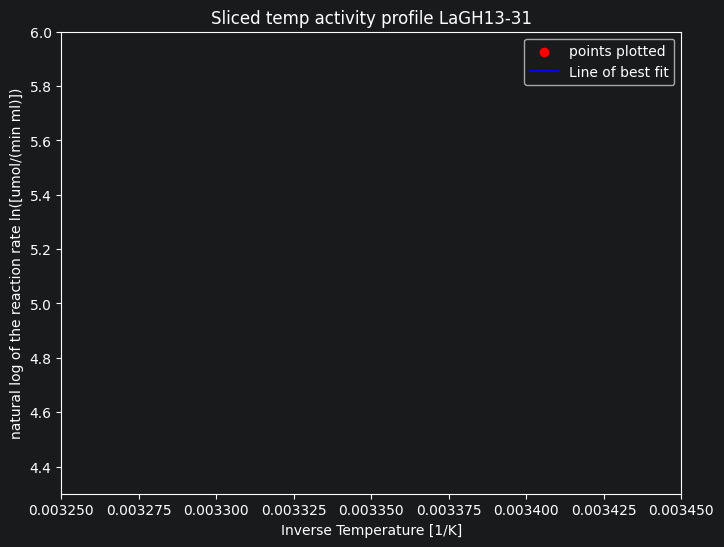

In [181]:
plt.figure(figsize=(8, 6))
plt.scatter(line_inv_temp, line_ln_velocity, color = 'red', label = "points plotted")
plt.plot(line_inv_temp, inter_vel + slope_vel*line_inv_temp, color = 'blue', label = 'Line of best fit')
plt.title("Sliced temp activity profile LaGH13-31")
plt.xlabel("Inverse Temperature [1/K]")
plt.ylabel("natural log of the reaction rate ln([umol/(min ml)])")
plt.xlim(0.00325, 0.00345)
plt.ylim(4.3, 6)
plt.legend()
plt.grid(False)
plt.show()

In [182]:
gas_constant = 8.3144626181532
L_to_uL = 10**6

#gradient multiplied by the gas constant
activation_energy = -gas_constant * (slope_vel / 10**6) * 10**3

print(f"activation energy: ", activation_energy)
print(f"log A: ", inter_vel)

activation energy:  0.5339315050844747
log A:  7.5603370840476956


# volume calculations

In [183]:
final_substrate_conc = 4 # mM
universal_final_vol = 500 # microliters
initial_substrate_conc = 20 #mM
L_to_uL = 10**6 #Liters to microliters

substrate_vol = (final_substrate_conc * universal_final_vol) / initial_substrate_conc
print(f"substrate volume: ", substrate_vol)
buffer_vol = 250 # microliters
enzyme_vol = 100 # microliters

water_vol = universal_final_vol - (buffer_vol + substrate_vol + enzyme_vol)

print(f"water volume: ", water_vol)

substrate volume:  100.0
water volume:  50.0


# Optimum pH

In [184]:
data_B_C = pd.read_csv("ex4_b.csv", sep = ";", decimal = ',')

reduced_data_B_C = data_B_C.iloc[:, :]

array_pH = reduced_data_B_C.to_numpy()

In [185]:
blank_mean = np.mean(array_pH[0, 9:13])

absorbance_no_blank = array_pH[:6, 1:6] - blank_mean

In [186]:
pNP_slope = 0.013400526315789474

pNP_inter = 0.011564912280701573

pipette_reaction_volume = 50

concentration_pNP_pH = (((absorbance_no_blank - pNP_inter) / pNP_slope) * buffer_vol) / pipette_reaction_volume

In [187]:
universal_time = np.array([0.5, 3.5, 6.5, 9.5, 12.5])

#Array with pH pNP concentration
pH_A = concentration_pNP_pH[0, :].astype(float) # pH 4.5
pH_B = concentration_pNP_pH[1, :].astype(float) # pH 5
pH_C = concentration_pNP_pH [2, :].astype(float) # pH 5.5
pH_D = concentration_pNP_pH[3, :].astype(float) # pH 6
pH_E = concentration_pNP_pH[4, :].astype(float) # pH 6.5
pH_F = concentration_pNP_pH[5, :].astype(float) # pH 7

In [188]:
a_slope, a_inter = np.polyfit(universal_time, pH_A, 1)
b_slope, b_inter = np.polyfit(universal_time, pH_B, 1)
c_slope, c_inter = np.polyfit(universal_time, pH_C, 1)
d_slope, d_inter = np.polyfit(universal_time, pH_D, 1)
e_slope, e_inter = np.polyfit(universal_time, pH_E, 1)
f_slope, f_inter = np.polyfit(universal_time, pH_F, 1)

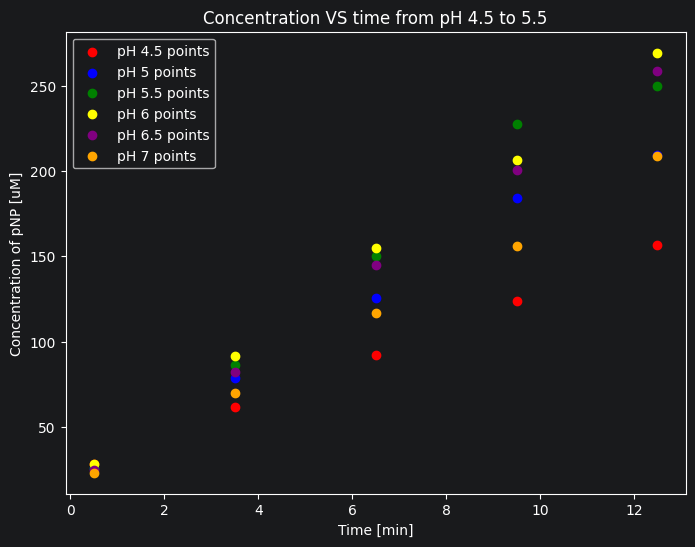

In [189]:
plt.figure(figsize=(8, 6))
plt.scatter(universal_time, pH_A, color ='red', label ="pH 4.5 points")
plt.scatter(universal_time, pH_B, color ='blue', label ="pH 5 points")
plt.scatter(universal_time, pH_C, color ='green', label ="pH 5.5 points")
plt.scatter(universal_time, pH_D, color ='yellow', label ="pH 6 points")
plt.scatter(universal_time, pH_E, color ='purple', label ="pH 6.5 points")
plt.scatter(universal_time, pH_F, color ='orange', label ="pH 7 points")

plt.title("Concentration VS time from pH 4.5 to 5.5")
plt.ylabel("Concentration of pNP [uM]")
plt.xlabel("Time [min]")
plt.legend()
plt.grid(False)
plt.show()

In [190]:
pH_A_gradient, pH_A_inter = np.polyfit(universal_time[:3], pH_A[:3], 1)
pH_B_gradient, pH_B_inter = np.polyfit(universal_time[:3], pH_B[:3], 1)
pH_C_gradient, pH_C_inter = np.polyfit(universal_time[:3], pH_C[:3], 1)
pH_D_gradient, pH_D_inter = np.polyfit(universal_time[:3], pH_D[:3], 1)
pH_E_gradient, pH_E_inter = np.polyfit(universal_time[:3], pH_E[:3], 1)
pH_F_gradient, pH_F_inter = np.polyfit(universal_time[:3], pH_F[:3], 1)

pH_rate = np.array([pH_A_gradient, pH_B_gradient, pH_C_gradient, pH_D_gradient, pH_E_gradient, pH_F_gradient])

pH_values = np.array([4.5, 5.0, 5.5, 6.0, 6.5, 7.0])

print(pH_rate)

[10.63391069 16.66601207 20.70814186 21.14344815 19.96190252 15.60883966]


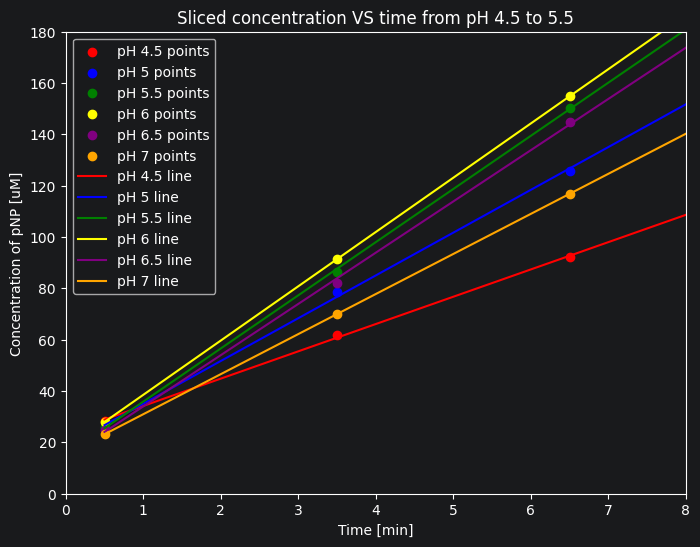

In [191]:
plt.figure(figsize=(8, 6))
plt.scatter(universal_time[:3], pH_A[:3], color ='red', label ="pH 4.5 points")
plt.scatter(universal_time[:3], pH_B[:3], color ='blue', label ="pH 5 points")
plt.scatter(universal_time[:3], pH_C[:3], color ='green', label ="pH 5.5 points")
plt.scatter(universal_time[:3], pH_D[:3], color ='yellow', label ="pH 6 points")
plt.scatter(universal_time[:3], pH_E[:3], color ='purple', label ="pH 6.5 points")
plt.scatter(universal_time[:3], pH_F[:3], color ='orange', label ="pH 7 points")

#Line of best fit
plt.plot(universal_time, pH_A_inter + pH_A_gradient * universal_time, color ='red', label ="pH 4.5 line")
plt.plot(universal_time, pH_B_inter + pH_B_gradient * universal_time, color ='blue', label ="pH 5 line")
plt.plot(universal_time, pH_C_inter + pH_C_gradient * universal_time, color ='green', label ="pH 5.5 line")
plt.plot(universal_time, pH_D_inter + pH_D_gradient * universal_time, color ='yellow', label ="pH 6 line")
plt.plot(universal_time, pH_E_inter + pH_E_gradient * universal_time, color ='purple', label ="pH 6.5 line")
plt.plot(universal_time, pH_F_inter + pH_F_gradient * universal_time, color ='orange', label ="pH 7 line")

plt.title("Sliced concentration VS time from pH 4.5 to 5.5")
plt.ylabel("Concentration of pNP [uM]")
plt.xlabel("Time [min]")
plt.legend()
plt.xlim(0,8)
plt.ylim(0,180)
plt.grid(False)
plt.show()

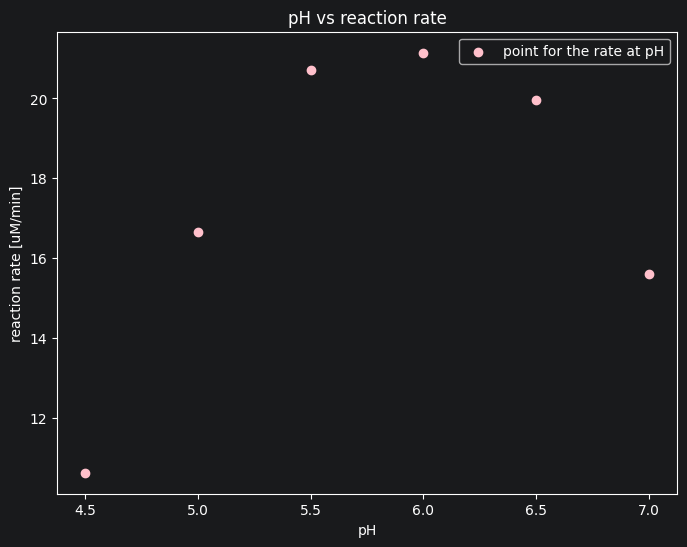

In [192]:
plt.figure(figsize=(8, 6))
plt.scatter(pH_values, pH_rate, color = 'pink', label = "point for the rate at pH")
plt.title("pH vs reaction rate")
plt.xlabel("pH")
plt.ylabel("reaction rate [uM/min]")
plt.legend()
plt.grid(False)
plt.show()

# Reaction rate, time and substrate concentration

In [193]:
final_volume = 500

assay_vol = 100
enzyme_mix = 100

final_l_conc = 0.4 # Low substrate conc
final_h_conc = 5 # High substrate conc

#initial volume of the substrate
initial_l_vol = (final_l_conc * final_volume) / initial_substrate_conc

initial_h_vol = (final_h_conc * final_volume) / initial_substrate_conc

print(f"L initial volume: ", initial_l_vol)
print(f"H initial volume: ", initial_h_vol)

#volume of water
volume_water_l = final_volume - initial_l_vol - assay_vol - enzyme_vol

volume_water_h = final_volume - initial_h_vol - assay_vol - enzyme_vol

print(f"L volume of water: ", volume_water_l)
print(f"H volume of water: ", volume_water_h)


L initial volume:  10.0
H initial volume:  125.0
L volume of water:  290.0
H volume of water:  175.0


In [194]:
data_c = pd.read_csv("ex4_c.csv", sep =";", decimal =',')

reduced_data_c = data_c.iloc[6:, 1:9]

data_c_array = reduced_data_c.to_numpy()


In [195]:
h_and_l_no_blank = data_c_array - blank_mean

concentration_p_np_hl = (((h_and_l_no_blank - pNP_inter) / pNP_slope) * 250) / 50

In [196]:
high_conc = concentration_p_np_hl[1, :].astype(float)

low_conc = concentration_p_np_hl[0, :].astype(float)
print(f"concentrations for pNP in H are {high_conc} uM \n Concentrations for pNP in L are {low_conc} uM")

concentrations for pNP in H are [ 53.7050129  110.7923229  167.50651323 223.47446421 280.18865454
 354.06634984 431.3021222  568.23704227] uM 
 Concentrations for pNP in L are [  6.69193407  22.73608002  35.42214891  48.1082178   63.4061244
  80.19650969  96.61377532 161.16347878] uM


In [197]:
time_c = np.array([0.5, 3.5, 6.5, 9.5, 12.5, 16.5, 20.5, 30.5])
h_slope, h_inter = np.polyfit(time_c, high_conc, 1)
l_slope, l_inter = np.polyfit(time_c, low_conc, 1)
print(h_slope)
print(l_slope)

17.474622559410992
4.974559916329822


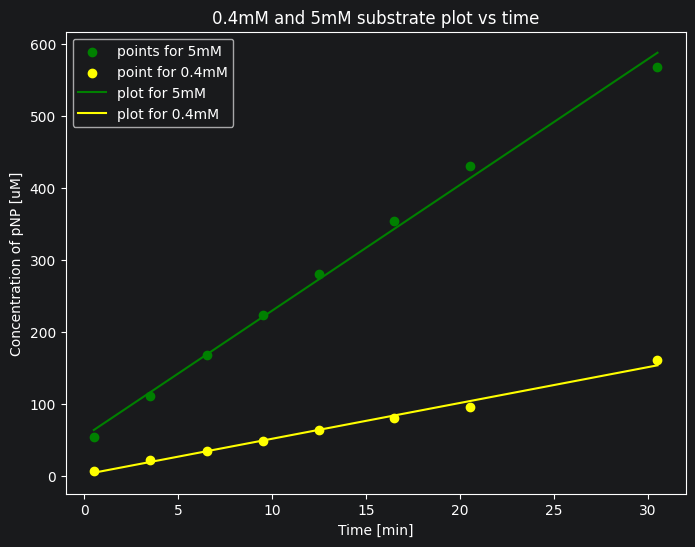

In [198]:
plt.figure(figsize=(8, 6))
plt.scatter(time_c, high_conc, color ='green', label ="points for 5mM")
plt.scatter(time_c, low_conc, color ='yellow', label ="point for 0.4mM")
plt.plot(time_c, h_inter + h_slope * time_c, color ='green', label ="plot for 5mM")
plt.plot(time_c, l_inter + l_slope * time_c, color ='yellow', label ="plot for 0.4mM")
plt.title("0.4mM and 5mM substrate plot vs time")
plt.xlabel("Time [min]")
plt.ylabel("Concentration of pNP [uM]")
plt.legend()
plt.grid(False)
plt.show()

In [199]:
sliced_time_hl = time_c[:4]

sliced_p_np_l = low_conc[:4]

sliced_p_np_h = high_conc[:4]

sliced_h_slope, sliced_h_inter = np.polyfit(sliced_time_hl, sliced_p_np_h, 1)

sliced_l_slope, sliced_l_inter = np.polyfit(sliced_time_hl, sliced_p_np_l, 1)

print(f"The slope of L is {sliced_l_slope} mM/min, and the slope for H is {sliced_h_slope} mM/min")

The slope of L is 4.564497335794611 mM/min, and the slope for H is 18.86741814278046 mM/min


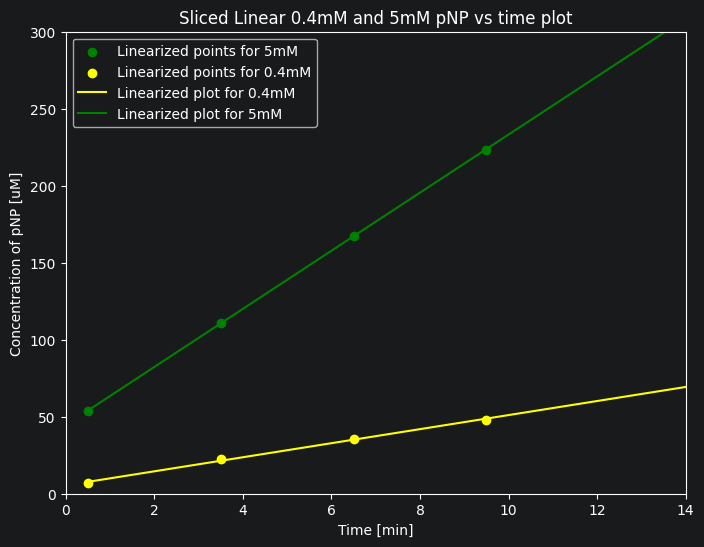

In [200]:
plt.figure(figsize=(8, 6))
plt.scatter(sliced_time_hl, sliced_p_np_h, color ='green', label ="Linearized points for 5mM")
plt.scatter(sliced_time_hl, sliced_p_np_l, color ='yellow', label ="Linearized points for 0.4mM")
plt.plot(time_c, sliced_l_inter + sliced_l_slope * time_c, color ='yellow', label ="Linearized plot for 0.4mM")
plt.plot(time_c, sliced_h_inter + sliced_h_slope * time_c, color ='green', label ="Linearized plot for 5mM")
plt.title("Sliced Linear 0.4mM and 5mM pNP vs time plot")
plt.xlabel("Time [min]")
plt.ylabel("Concentration of pNP [uM]")
plt.xlim(0, 14)
plt.ylim(0,300)
plt.legend()
plt.grid(False)
plt.show()

In [201]:
from scipy.stats import linregress
res_L = linregress(sliced_time_hl, sliced_p_np_l)
res_H = linregress(sliced_time_hl, sliced_p_np_h)
L_intercept = res_L.intercept
l_slope = res_H.slope
conc_low_R = res_L.rvalue
conc_low_R2 = res_L.rvalue**2

conc_high_R = res_H.rvalue
conc_high_R2 = conc_high_R**2
conc_low_R2_percent = conc_low_R2*100
conc_high_R2_percentage = conc_high_R2 * 100

print(f"R^2 value @ low substrate volume: {l_slope:.3f}")
print(f"R^2 value @ loq substrate volume as a percentage: {conc_low_R2_percent:.2f}%")

print(f"R^2 value @ high substrate volume: {h_slope:.2f}")
print(f"R^2 value @ loq substrate volume as a percentage: {conc_high_R2_percentage:.2f}%")


R^2 value @ low substrate volume: 18.867
R^2 value @ loq substrate volume as a percentage: 99.64%
R^2 value @ high substrate volume: 17.47
R^2 value @ loq substrate volume as a percentage: 100.00%


# D1 data

In [202]:
data_completed = pd.read_csv('ex4_all_data.csv', sep = ";", decimal = ',')

reduced_data_d1 = data_completed.iloc[:, 1:6]

array_d1 = reduced_data_d1.to_numpy()

In [203]:
substrate_conc = np.array([0.6, 1, 2, 4, 8, 12])

In [204]:
abs_mean_blank = np.mean(array_d1[7, 1:3])
abs_s_noblank = array_d1[:6, :] - abs_mean_blank

conc_pNP_noInhibition = (((abs_s_noblank - pNP_inter) / pNP_slope) * 250) / 50

In [205]:
#substrate concentrations in each row
s1_a = conc_pNP_noInhibition[0, :]
s2_a = conc_pNP_noInhibition[1,:]
s3_a = conc_pNP_noInhibition[2, :]
s4_a = conc_pNP_noInhibition[3, :]
s5_a = conc_pNP_noInhibition[4, :]
s6_a = conc_pNP_noInhibition[5, :]


In [206]:
#make sure to slice it
s1_slope, s1_inter = np.polyfit(universal_time[:3], s1_a[:3], 1)
s2_slope, s2_inter = np.polyfit(universal_time[:3], s2_a[:3], 1)
s3_slope, s3_inter = np.polyfit(universal_time[:3], s3_a[:3], 1)
s4_slope, s4_inter = np.polyfit(universal_time[:3], s4_a[:3], 1)
s5_slope, s5_inter = np.polyfit(universal_time[:3], s5_a[:3], 1)
s6_slope, s6_inter = np.polyfit(universal_time[:3], s6_a[:3], 1)

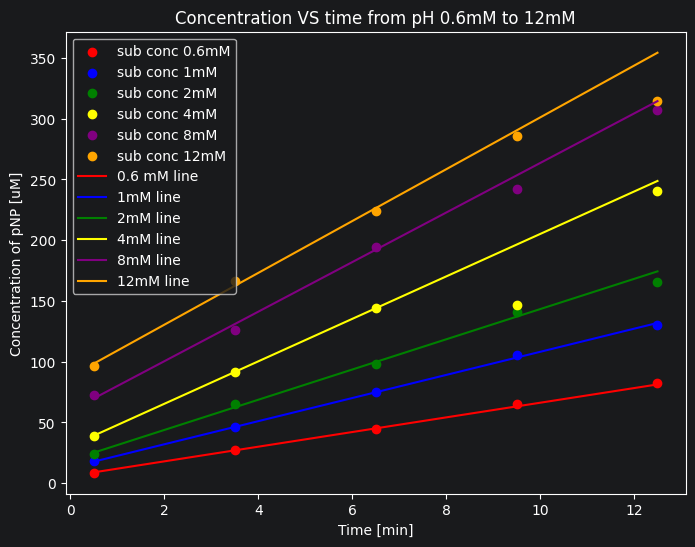

In [207]:
plt.figure(figsize=(8, 6))
plt.scatter(universal_time, s1_a, color ='red', label ="sub conc 0.6mM")
plt.scatter(universal_time, s2_a, color ='blue', label ="sub conc 1mM")
plt.scatter(universal_time, s3_a, color ='green', label ="sub conc 2mM")
plt.scatter(universal_time, s4_a, color ='yellow', label ="sub conc 4mM")
plt.scatter(universal_time, s5_a, color ='purple', label ="sub conc 8mM")
plt.scatter(universal_time, s6_a, color ='orange', label ="sub conc 12mM")

#Line of best fit
plt.plot(universal_time, s1_inter + s1_slope * universal_time, color ='red', label ="0.6 mM line")
plt.plot(universal_time, s2_inter + s2_slope * universal_time, color ='blue', label ="1mM line")
plt.plot(universal_time, s3_inter + s3_slope * universal_time, color ='green', label ="2mM line")
plt.plot(universal_time, s4_inter + s4_slope * universal_time, color ='yellow', label ="4mM line")
plt.plot(universal_time, s5_inter + s5_slope * universal_time, color ='purple', label ="8mM line")
plt.plot(universal_time, s6_inter + s6_slope * universal_time, color ='orange', label ="12mM line")

plt.title("Concentration VS time from pH 0.6mM to 12mM")
plt.ylabel("Concentration of pNP [uM]")
plt.xlabel("Time [min]")
plt.legend()
plt.grid(False)
plt.show()

In [208]:
gradients_without_inhibition= np.array([s1_slope, s2_slope, s3_slope, s4_slope, s5_slope, s6_slope])

print(f"Gradient for each concentration {gradients_without_inhibition}")

Gradient for each concentration [ 6.03210138  9.51455167 12.43732244 17.47443803 20.3972088  21.33000799]


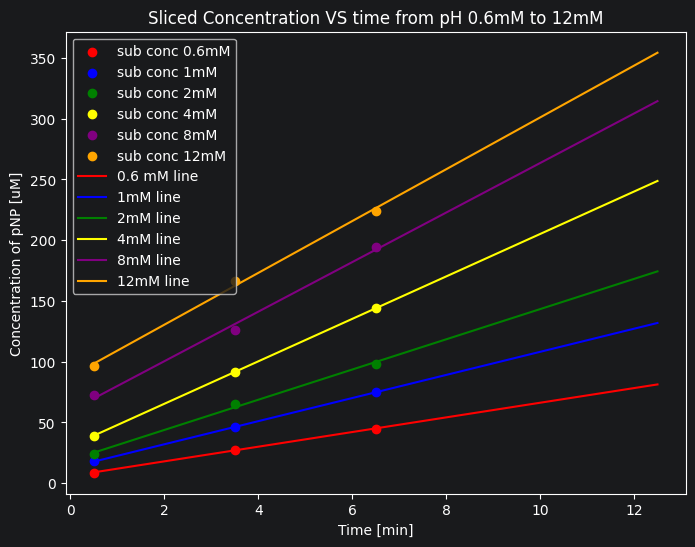

In [209]:
#remember to slice this
plt.figure(figsize=(8, 6))
plt.scatter(universal_time[0:3], s1_a[:3], color ='red', label ="sub conc 0.6mM")
plt.scatter(universal_time[:3], s2_a[:3], color ='blue', label ="sub conc 1mM")
plt.scatter(universal_time[:3], s3_a[:3], color ='green', label ="sub conc 2mM")
plt.scatter(universal_time[:3], s4_a[:3], color ='yellow', label ="sub conc 4mM")
plt.scatter(universal_time[:3], s5_a[:3], color ='purple', label ="sub conc 8mM")
plt.scatter(universal_time[:3], s6_a[:3], color ='orange', label ="sub conc 12mM")


#Line of best fit
plt.plot(universal_time, s1_inter + s1_slope * universal_time, color ='red', label ="0.6 mM line")
plt.plot(universal_time, s2_inter + s2_slope * universal_time, color ='blue', label ="1mM line")
plt.plot(universal_time, s3_inter + s3_slope * universal_time, color ='green', label ="2mM line")
plt.plot(universal_time, s4_inter + s4_slope * universal_time, color ='yellow', label ="4mM line")
plt.plot(universal_time, s5_inter + s5_slope * universal_time, color ='purple', label ="8mM line")
plt.plot(universal_time, s6_inter + s6_slope * universal_time, color ='orange', label ="12mM line")


plt.title("Sliced Concentration VS time from pH 0.6mM to 12mM")
plt.ylabel("Concentration of pNP [uM]")
plt.xlabel("Time [min]")
plt.legend()
plt.grid(False)
plt.show()

In [210]:
inverse_vel = 1 / gradients_without_inhibition

inverse_sub = 1 / substrate_conc

burk_plot_slope, burk_plot_inter = np.polyfit(inverse_sub, inverse_vel, 1)

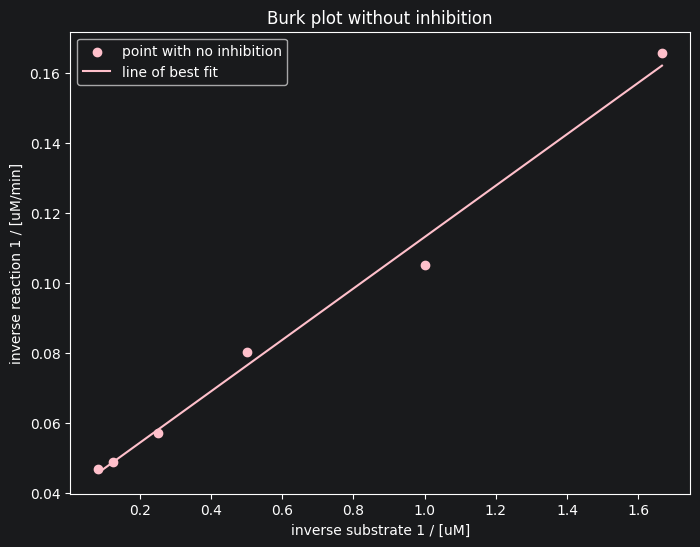

In [211]:
plt.figure(figsize = (8, 6))
plt.scatter(inverse_sub, inverse_vel, color ='pink', label ="point with no inhibition")

plt.plot(inverse_sub, burk_plot_inter + burk_plot_slope * inverse_sub, color = 'pink', label = "line of best fit")

plt.title("Burk plot without inhibition")
plt.ylabel("inverse reaction 1 / [uM/min]")
plt.xlabel("inverse substrate 1 / [uM]")
plt.legend()
plt.grid(False)
plt.show()

In [212]:
R_burk = linregress(inverse_sub, inverse_vel)
conc_burk_R = R_burk.rvalue
conc_burk_R2 = R_burk.rvalue**2

print(f"R^2 burk plot R^2 value: {conc_burk_R2}%")

R^2 burk plot R^2 value: 0.9908391952168366%


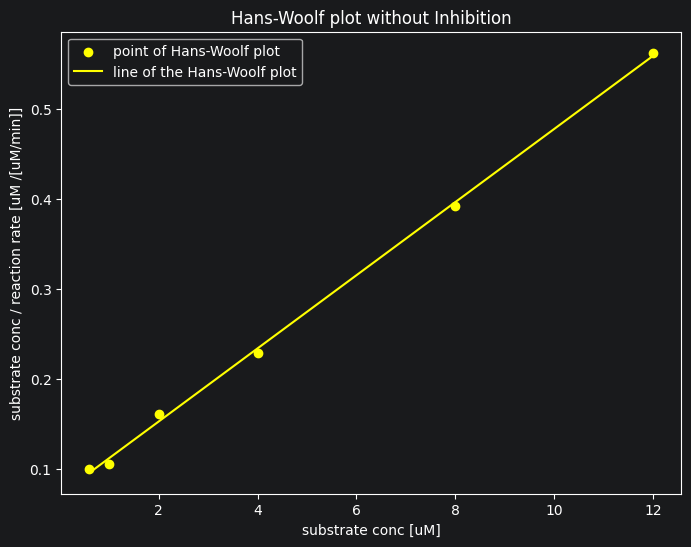

In [213]:
hw_velocity = substrate_conc / gradients_without_inhibition

hw_slope, hw_inter = np.polyfit(substrate_conc, hw_velocity, 1)

plt.figure(figsize=(8, 6))
plt.scatter(substrate_conc, hw_velocity, color = 'yellow', label = "point of Hans-Woolf plot")

plt.plot(substrate_conc, hw_inter + hw_slope * substrate_conc, color = 'yellow', label = "line of the Hans-Woolf plot")

plt.title("Hans-Woolf plot without Inhibition")
plt.ylabel("substrate conc / reaction rate [uM /[uM/min]]")
plt.xlabel("substrate conc [uM]")
plt.legend()
plt.grid(False)
plt.show()

In [214]:
hw_lineregress = linregress(substrate_conc, hw_velocity)
R_hw_value = R_burk.rvalue
hw_R2 = R_burk.rvalue ** 2

print(f"R^2 burk plot R^2 value: {hw_R2}%")

R^2 burk plot R^2 value: 0.9908391952168366%


In [215]:
vmax_burk = 1 / burk_plot_inter

km_burk = vmax_burk * burk_plot_slope

vmax_hw = 1 / hw_slope

km_hw = vmax_hw * hw_inter

print(f"Burk plot Vmax is {vmax_burk} and Km is {km_burk}. \n Hans-Woolf plot Vmax is {vmax_hw} and Km is {km_hw}")

Burk plot Vmax is 25.185907104516296 and Km is 1.8494559572830072. 
 Hans-Woolf plot Vmax is 24.58591856477909 and Km is 1.7475937450465915


In [216]:
initial_enzyme_conc = 10 / 10**3 #nm to uM
initial_enzyme_volume = 50

enzyme_conc = initial_enzyme_conc * initial_enzyme_volume / universal_final_vol

k_cat_burk = vmax_burk / enzyme_conc

k_cat_hw = vmax_hw / enzyme_conc

print(f"Kcat for burk is {k_cat_burk}, and Kcat for Hans-Woolf is {k_cat_hw}")

Kcat for burk is 25185.907104516296, and Kcat for Hans-Woolf is 24585.918564779087


# D2 data process

In [217]:
borrowed_data = pd.read_csv("d2_team17.csv", sep=";", decimal= ',')
reduced_data_2d = borrowed_data.iloc[:, :]

array_d2 = reduced_data_2d.to_numpy()

In [218]:
borrowed_mean = np.mean(array_d2[7, 1:3])
d2_subtraction_blank = array_d2[:6, 8:13].astype(float) - borrowed_mean
conc_pNP_inhibition = (((d2_subtraction_blank - pNP_inter) / pNP_slope) * 250) / 50
#concentration affected by glucose
i1 = conc_pNP_inhibition[0,:]
i2 = conc_pNP_inhibition[1,:]
i3 = conc_pNP_inhibition[2,:]
i4 = conc_pNP_inhibition[3,:]
i5 = conc_pNP_inhibition[4,:]
i6 = conc_pNP_inhibition[5,:]

print(i1)

[-2.8226176   3.89353652 10.98281031 18.81832345 26.65383659]


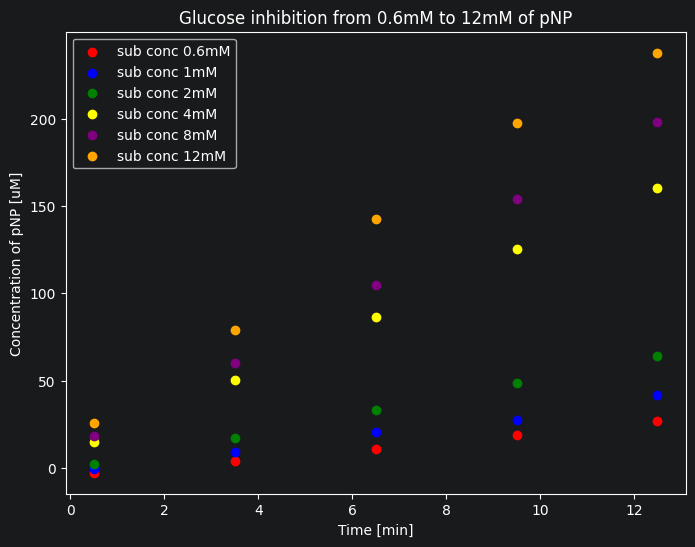

In [219]:

plt.figure(figsize=(8, 6))
plt.scatter(universal_time, i1, color ='red', label ="sub conc 0.6mM")
plt.scatter(universal_time, i2, color ='blue', label ="sub conc 1mM")
plt.scatter(universal_time, i3, color ='green', label ="sub conc 2mM")
plt.scatter(universal_time, i4, color ='yellow', label ="sub conc 4mM")
plt.scatter(universal_time, i5, color ='purple', label ="sub conc 8mM")
plt.scatter(universal_time, i6, color ='orange', label ="sub conc 12mM")

plt.title("Glucose inhibition from 0.6mM to 12mM of pNP")
plt.ylabel("Concentration of pNP [uM]")
plt.xlabel("Time [min]")
plt.legend()
plt.grid(False)
plt.show()

In [220]:
#make sure to slice it
i1_slope, i1_inter = np.polyfit(universal_time[:3], i1[:3], 1)
i2_slope, i2_inter = np.polyfit(universal_time[:3], i2[:3], 1)
i3_slope, i3_inter = np.polyfit(universal_time[:3], i3[:3], 1)
i4_slope, i4_inter = np.polyfit(universal_time[:3], i4[:3], 1)
i5_slope, i5_inter = np.polyfit(universal_time[:3], i5[:3], 1)
i6_slope, i6_inter = np.polyfit(universal_time[:3], i6[:3], 1)

inhibition_gradients = np.array([i1_slope, i2_slope, i3_slope, i4_slope, i5_slope, i6_slope])

print(f"inhibition gradients {inhibition_gradients}")

inhibition gradients [ 2.30090465  3.48245028  5.16148881 11.93982954 14.42729403 19.52659623]


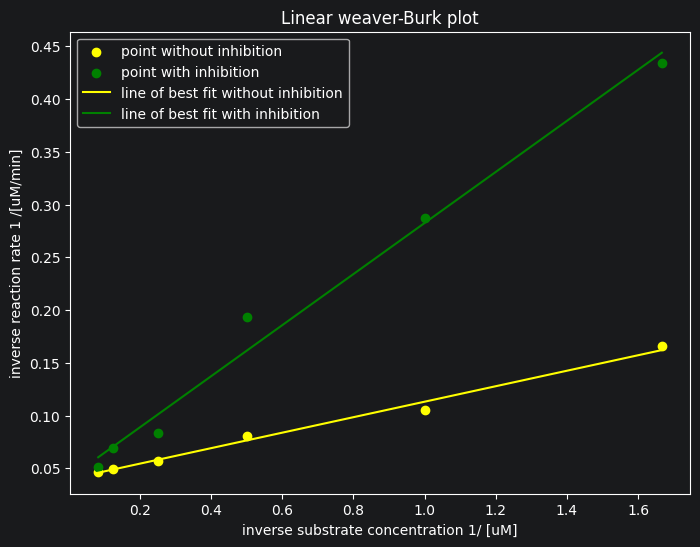

In [221]:
i_burk_vel = 1 / inhibition_gradients

#concentration_trial = np.array([0.6, 2, 4, 8, 12])
inhibited_burk_slope, inhibited_burk_inter = np.polyfit(inverse_sub, i_burk_vel, 1)

plt.figure(figsize=(8, 6))
plt.scatter(inverse_sub, inverse_vel, color = 'yellow', label = "point without inhibition")
plt.scatter(inverse_sub, i_burk_vel, color = 'green', label = "point with inhibition")
plt.plot(inverse_sub, burk_plot_inter + burk_plot_slope * inverse_sub, color = 'yellow', label = "line of best fit without inhibition")
plt.plot(inverse_sub, inhibited_burk_inter + inhibited_burk_slope * inverse_sub, color ='green', label ="line of best fit with inhibition")
plt.title("Linear weaver-Burk plot")
plt.ylabel("inverse reaction rate 1 /[uM/min]")
plt.xlabel("inverse substrate concentration 1/ [uM]")
plt.legend()
plt.grid(False)
plt.show()

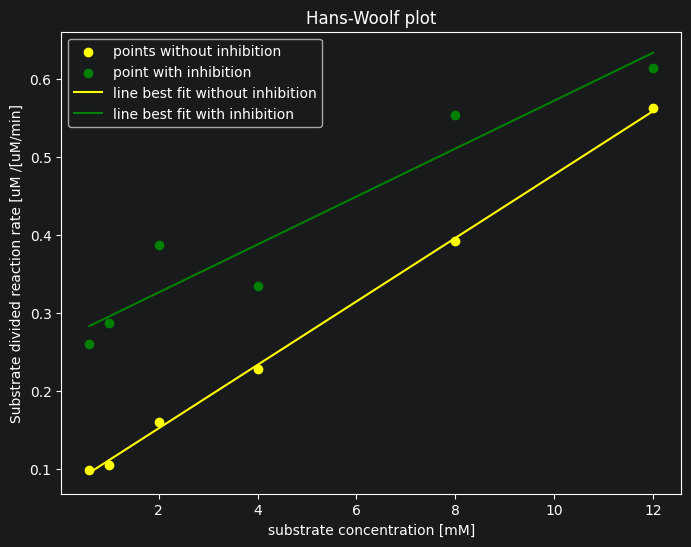

In [222]:
#
inhibited_hw_values = substrate_conc / inhibition_gradients
inhibited_hw_slope, inhibited_hw_inter = np.polyfit(substrate_conc, inhibited_hw_values, 1)

plt.figure(figsize=(8, 6))
plt.scatter(substrate_conc, hw_velocity, color = 'yellow', label = "points without inhibition")
plt.scatter(substrate_conc, inhibited_hw_values, color ='green', label ="point with inhibition")
plt.plot(substrate_conc, hw_inter + hw_slope * substrate_conc, color = 'yellow', label = "line best fit without inhibition")
plt.plot(substrate_conc, inhibited_hw_inter + inhibited_hw_slope * substrate_conc, color ='green', label ="line best fit with inhibition")

plt.title("Hans-Woolf plot")
plt.ylabel("Substrate divided reaction rate [uM /[uM/min]")
plt.xlabel("substrate concentration [mM]")
plt.legend()
plt.grid(False)
plt.show()

In [223]:
inhibited_vmax_burk = 1 / inhibited_burk_inter

inhibited_km_burk = inhibited_vmax_burk * inhibited_burk_slope

inhibited_vmax_hw = 1 / inhibited_hw_slope

inhibited_km_hw = inhibited_vmax_hw * inhibited_hw_inter

print(f"inhibition of Burks Vmax is {inhibited_vmax_burk} and Km is {inhibited_km_burk}. \n inhibition Hans-Woolf Vmax is {inhibited_vmax_hw} and Km is {inhibited_km_hw}")

inhibition of Burks Vmax is 24.816936692889588 and Km is 6.010946428265977. 
 inhibition Hans-Woolf Vmax is 32.53203112470572 and Km is 8.626820930678658


In [224]:
#abstract Ki for inhibition
initial_glucose_conc = 60 #mM
initial_glucose_volume = 50 #uL
glucose_conc = ((initial_glucose_conc * initial_glucose_volume) / universal_final_vol)

ki_hw = (glucose_conc) / ((inhibited_hw_inter / (km_hw/vmax_hw)) - 1)

ki_burk = glucose_conc / ((inhibited_burk_slope / (km_burk / vmax_burk)) - 1)

print(f"inhibition equilibrium constant from Line weaver Burk plot: ", ki_burk)
print(f"inhibition equilibrium constant from Hanes-Wolff plot: ", ki_hw)

inhibition equilibrium constant from Line weaver Burk plot:  2.610468819546526
inhibition equilibrium constant from Hanes-Wolff plot:  2.19727174489167


In [225]:
#specific Ki for competitive inhibition
specific_ki_hw = glucose_conc / ((inhibited_km_hw / km_hw ) - 1)

specific_ki_burk = glucose_conc / ((inhibited_km_burk / km_burk) - 1)

print(f"inhibition constant with the known inhibition mechanism (competitive) for the Line weaver Burk plot", specific_ki_burk)
print(f"inhibition constant with the known inhibition mechanism (competitive) for the Hanes-Woolf plot",specific_ki_hw)

inhibition constant with the known inhibition mechanism (competitive) for the Line weaver Burk plot 2.6665291729184055
inhibition constant with the known inhibition mechanism (competitive) for the Hanes-Woolf plot 1.5242355263654705


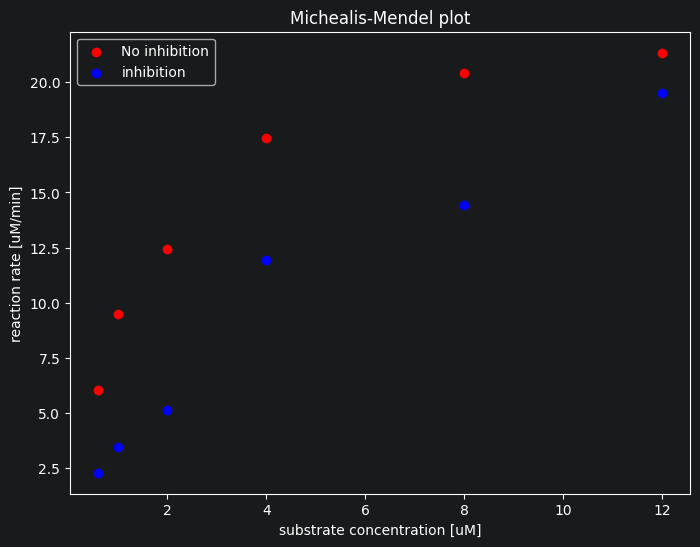

In [226]:
#micheal-mendel
plt.figure(figsize=(8, 6))
plt.scatter(substrate_conc, gradients_without_inhibition, color = 'red', label = "No inhibition")
plt.scatter(substrate_conc, inhibition_gradients, color = 'blue', label = "inhibition")
plt.title("Michealis-Mendel plot")
plt.ylabel("reaction rate [uM/min]")
plt.xlabel("substrate concentration [uM]")
plt.legend()
plt.grid(False)
plt.show()